# MNIST digit recognition with TensorFlow and Keras

Most code from Deep Learning with Python, Second Edition - François Chollet (2021).

The "OLD VERSION" commented code refers to the (deprecated) version used in the first edition of the book.

TODO: reproducibility

## Dataset

### Load

In [1]:
from tensorflow.keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [2]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

In [3]:
type(train_images), type(train_labels), type(test_images), type(test_labels)

(numpy.ndarray, numpy.ndarray, numpy.ndarray, numpy.ndarray)

### Prepare

In [4]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype("float32") / 255

In [5]:
test_labels[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9], dtype=uint8)

In [6]:
## OLD VERSION (needed)
#from keras.utils import to_categorical
#train_labels = to_categorical(train_labels)
#test_labels = to_categorical(test_labels)

In [7]:
train_images.shape, train_labels.shape, test_images.shape, test_labels.shape

((60000, 784), (60000,), (10000, 784), (10000,))

## Model

### Build architecture

In [8]:
## OLD VERSION (works too)
#from keras import models
#from keras import layers
#
#model = models.Sequential()
#model.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
#model.add(layers.Dense(10, activation='softmax'))

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

### Compile

In [10]:
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

TODO: WARNING:tensorflow:TensorFlow GPU support is not available on native Windows for TensorFlow >= 2.11. Even if CUDA/cuDNN are installed, GPU will not be used. Please use WSL2 or the TensorFlow-DirectML plugin.

### Fit

In [11]:
model.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9242 - loss: 0.2649
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9688 - loss: 0.1078
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9790 - loss: 0.0705
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9852 - loss: 0.0506
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9890 - loss: 0.0376


## Results

### Predictions

In [12]:
test_digits = test_images[0:10]
predictions = model.predict(test_digits)
predictions[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


array([8.5861487e-08, 1.5468904e-08, 1.8512752e-05, 8.4142463e-05,
       1.5175475e-11, 1.0439355e-07, 1.5294351e-11, 9.9989331e-01,
       7.1396408e-07, 3.0962706e-06], dtype=float32)

In [13]:
predictions[0].argmax()

np.int64(7)

### Accuracy

In [14]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"test_acc: {test_acc:.3%}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9788 - loss: 0.0673
test_acc: 97.880%


### Show

In [15]:
digit = train_images[4]
digit = digit.reshape(28, 28)

In [16]:
## OLD VERSION (fix, for some reason)
#import os
#os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

In [17]:
import matplotlib.pyplot as plt

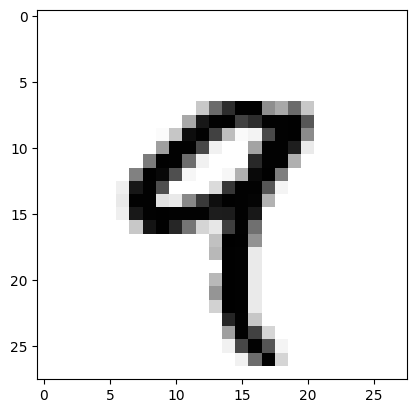

In [18]:
plt.imshow(digit, cmap=plt.cm.binary)

Plot wrongly labeled digits in test

In [19]:
import numpy as np

In [20]:
pred = np.argmax(model.predict(test_images), axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 964us/step


In [21]:
## OLD VERSION
#real = np.argmax(test_labels, axis=1)

real = test_labels.astype(np.int64)

In [22]:
neqs = (pred != real)
neqs = np.where(neqs)[0]
len(neqs)

212

In [23]:
nrows, ncols = 12, 10

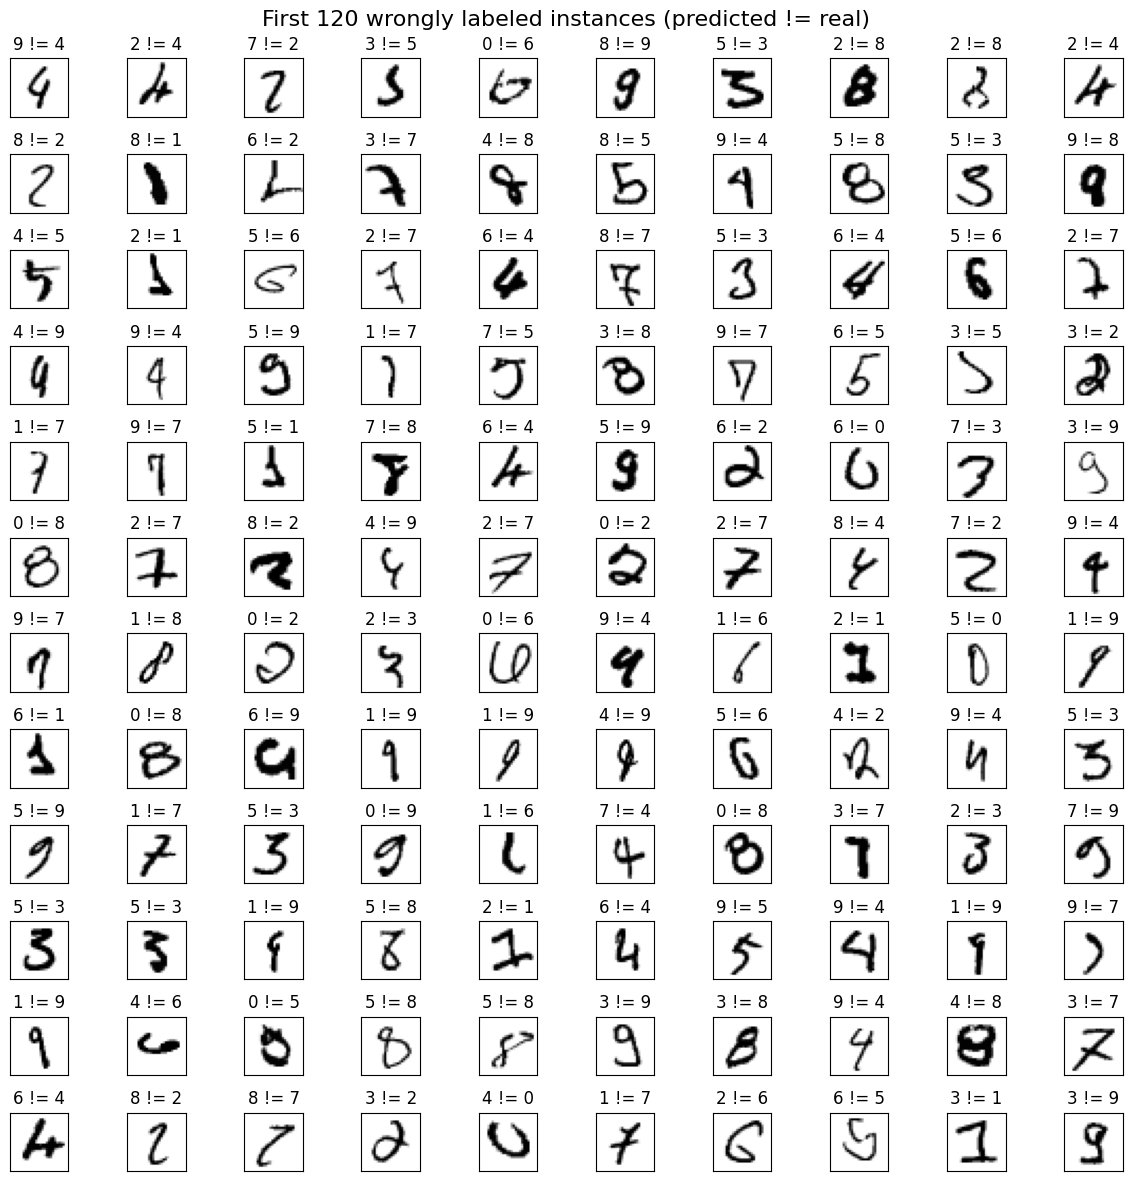

In [24]:
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 12))
axs = axs.flatten()

for i, ax in enumerate(axs):
    idx = neqs[i]
    ax.set_title(f"{pred[idx]} != {real[idx]}")
    digit = test_images[idx]
    digit = digit.reshape(28, 28)
    ax.imshow(digit, cmap=plt.cm.binary)
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f"First {nrows * ncols} wrongly labeled instances (predicted != real)", fontsize=16)
fig.tight_layout()